In [1]:
from __future__ import print_function
import os
import sys

# Temporary workaround for Windows OpenMP duplicate runtime initialization in notebooks.
# Must be set before importing torch/torchvision/numpy-linked libraries.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

# Set up absolute path to the root of the project for importing custom modules.
sys.path.append(os.path.abspath("../.."))

# Import necessary torch libraries
import torch
import torch.optim as optim
import torchvision.transforms as transforms

# Import Model
from models.RESNET.RESNET_b import ResNet, ResidualBlock

# Import utils
from utils.train_val_utils import train_and_evaluate
from utils.dataloader_utils import dataloader
from utils.display_image_utils import display_original_vs_augmented
from utils.show_best_model_utils import show_best_model
from utils.load_best_model_utils import load_best_model
from utils.retrieve_results_from_ckpt_utils import results_from_ckpt
from utils.plot_train_val_curve_utils import plot_training_curves

# Set random seed for reproducibility
torch.manual_seed(42)

In [2]:
use_cuda = True
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if (use_cuda and torch.cuda.is_available()) else "cpu")
print(f"Using device: {device}")

CUDA available: True
Using device: cuda


In [3]:
# Tensor conversion
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load datasets and dataloaders without augmentation for training dataset
train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader = dataloader(
    train_root="../../butterfly_anomaly_image_resized/final_dataset/train",
    val_root="../../butterfly_anomaly_image_resized/final_dataset/val",
    test_root="../../butterfly_anomaly_image_resized/final_dataset/test",
    transform_train=transform,
    transform_eval=transform,
    batch_size=32,
    num_workers=4
)

Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 3538
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 442
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 444


Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 3538
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 442
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 444


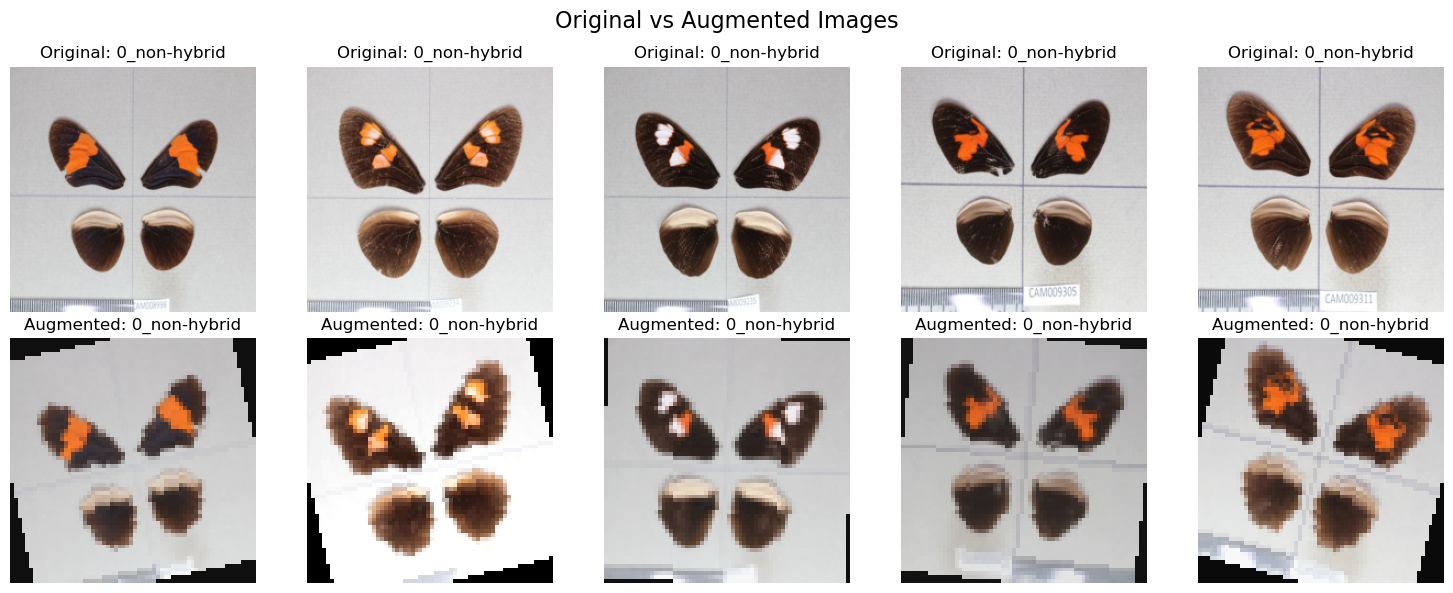

In [4]:
# Data augmentation transforms for training dataset
transform_train = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

# Data augmentation transforms for validation and test datasets (only resizing and tensor conversion)
transform_eval = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

# Load datasets and dataloaders with augmentation for training dataset
train_dataset_aug, val_dataset, test_dataset, train_loader_aug, val_loader, test_loader = dataloader(
    train_root="../../butterfly_anomaly_image_resized/final_dataset/train",
    val_root="../../butterfly_anomaly_image_resized/final_dataset/val",
    test_root="../../butterfly_anomaly_image_resized/final_dataset/test",
    transform_train=transform_train,
    transform_eval=transform_eval,
    batch_size=32,
    num_workers=4
)

assert train_dataset_aug.class_to_idx == val_dataset.class_to_idx == test_dataset.class_to_idx

display_original_vs_augmented(train_dataset, train_dataset_aug)

In [ ]:
learning_rate_values = [0.01, 0.005, 0.001, 0.0001]
weight_decay_values = [1e-3, 1e-4, 1e-5, 1e-6]
class_weights_values = [2.5, 3.5, 4.5, 5.5]
batch_size_values = [16, 32, 64, 128]
layer_configurations = [[2, 2, 2], [3, 2, 2], [3, 3, 3], [4, 3, 3]]

model_resnet_b_dict = {}
optimizer_b_dict = {}
results_b_dict = {}
best_b_dict = {}
best_f2_b_dict = {}

count = 1

best_learning_rate_dict = {}
best_weight_decay_dict = {}
best_class_weights_val_dict = {}
best_batch_size_dict = {}
best_layer_configuration_dict = {}

best_learning_rate = 0.01
best_weight_decay = 1e-3
best_class_weights_val = 2.5
best_batch_size = 16
best_layer_configuration = [2, 2, 2]

best_f2 = float("-inf")

# Hyperparameter tuning for learning rate
for learning_rate in learning_rate_values:
    model_resnet_b_dict[f"model_resnet_b{count}"] = ResNet(ResidualBlock, best_layer_configuration, num_classes=2).to(device)
    optimizer_b_dict[f"optimizer_b{count}"] = optim.Adam(model_resnet_b_dict[f"model_resnet_b{count}"].parameters(), lr=learning_rate, weight_decay=best_weight_decay)
    print(f"\nTraining RESNET Model B{count} with learning rate {learning_rate}")
    results_b_dict[f"results_b{count}"] = train_and_evaluate(model_resnet_b_dict[f"model_resnet_b{count}"], train_dataset_aug, val_dataset, optimizer_b_dict[f"optimizer_b{count}"], num_epochs=30, batch_size=best_batch_size, class_weights_val=best_class_weights_val, ckpt_file=f"../../saved_models/resnet/resnet_b/resnet_model_b{count}_log.pkl", device=device, num_workers=0)
    best_b_dict[f"best_b{count}"], best_f2_b_dict[f"best_f2_b{count}"] = show_best_model(model_resnet_b_dict[f"model_resnet_b{count}"], ckpt_file=f"../../saved_models/resnet/resnet_b/resnet_model_b{count}_log.pkl")
    best_learning_rate_dict[f"best_learning_rate_b{count}"] = learning_rate
    best_weight_decay_dict[f"best_weight_decay_b{count}"] = best_weight_decay
    best_class_weights_val_dict[f"best_class_weights_val_b{count}"] = best_class_weights_val
    best_batch_size_dict[f"best_batch_size_b{count}"] = best_batch_size
    best_layer_configuration_dict[f"best_layer_configuration_b{count}"] = best_layer_configuration
    count += 1
    if best_f2_b_dict[f"best_f2_b{count-1}"] > best_f2:
        best_learning_rate = learning_rate
        best_f2 = best_f2_b_dict[f"best_f2_b{count-1}"]

# Hyperparameter tuning for weight decay
for weight_decay in weight_decay_values[1:]:
    model_resnet_b_dict[f"model_resnet_b{count}"] = ResNet(ResidualBlock, best_layer_configuration, num_classes=2).to(device)
    optimizer_b_dict[f"optimizer_b{count}"] = optim.Adam(model_resnet_b_dict[f"model_resnet_b{count}"].parameters(), lr=best_learning_rate, weight_decay=weight_decay)
    print(f"\nTraining RESNET Model B{count} with weight decay {weight_decay}")
    results_b_dict[f"results_b{count}"] = train_and_evaluate(model_resnet_b_dict[f"model_resnet_b{count}"], train_dataset_aug, val_dataset, optimizer_b_dict[f"optimizer_b{count}"], num_epochs=30, batch_size=best_batch_size, class_weights_val=best_class_weights_val, ckpt_file=f"../../saved_models/resnet/resnet_b/resnet_model_b{count}_log.pkl", device=device, num_workers=0)
    best_b_dict[f"best_b{count}"], best_f2_b_dict[f"best_f2_b{count}"] = show_best_model(model_resnet_b_dict[f"model_resnet_b{count}"], ckpt_file=f"../../saved_models/resnet/resnet_b/resnet_model_b{count}_log.pkl")
    best_learning_rate_dict[f"best_learning_rate_b{count}"] = best_learning_rate
    best_weight_decay_dict[f"best_weight_decay_b{count}"] = weight_decay
    best_class_weights_val_dict[f"best_class_weights_val_b{count}"] = best_class_weights_val
    best_batch_size_dict[f"best_batch_size_b{count}"] = best_batch_size
    best_layer_configuration_dict[f"best_layer_configuration_b{count}"] = best_layer_configuration
    count += 1
    if best_f2_b_dict[f"best_f2_b{count-1}"] > best_f2:
        best_weight_decay = weight_decay
        best_f2 = best_f2_b_dict[f"best_f2_b{count-1}"]

# Hyperparameter tuning for class weights
for class_weights_val in class_weights_values[1:]:
    model_resnet_b_dict[f"model_resnet_b{count}"] = ResNet(ResidualBlock, best_layer_configuration, num_classes=2).to(device)
    optimizer_b_dict[f"optimizer_b{count}"] = optim.Adam(model_resnet_b_dict[f"model_resnet_b{count}"].parameters(), lr=best_learning_rate, weight_decay=best_weight_decay)
    print(f"\nTraining RESNET Model B{count} with class weights {class_weights_val}")
    results_b_dict[f"results_b{count}"] = train_and_evaluate(model_resnet_b_dict[f"model_resnet_b{count}"], train_dataset_aug, val_dataset, optimizer_b_dict[f"optimizer_b{count}"], num_epochs=30, batch_size=best_batch_size, class_weights_val=class_weights_val, ckpt_file=f"../../saved_models/resnet/resnet_b/resnet_model_b{count}_log.pkl", device=device, num_workers=0)
    best_b_dict[f"best_b{count}"], best_f2_b_dict[f"best_f2_b{count}"] = show_best_model(model_resnet_b_dict[f"model_resnet_b{count}"], ckpt_file=f"../../saved_models/resnet/resnet_b/resnet_model_b{count}_log.pkl")
    best_learning_rate_dict[f"best_learning_rate_b{count}"] = best_learning_rate
    best_weight_decay_dict[f"best_weight_decay_b{count}"] = best_weight_decay
    best_class_weights_val_dict[f"best_class_weights_val_b{count}"] = class_weights_val
    best_batch_size_dict[f"best_batch_size_b{count}"] = best_batch_size
    best_layer_configuration_dict[f"best_layer_configuration_b{count}"] = best_layer_configuration
    count += 1
    if best_f2_b_dict[f"best_f2_b{count-1}"] > best_f2:
        best_class_weights_val = class_weights_val
        best_f2 = best_f2_b_dict[f"best_f2_b{count-1}"]

# Hyperparameter tuning for batch size
for batch_size in batch_size_values[1:]:
    model_resnet_b_dict[f"model_resnet_b{count}"] = ResNet(ResidualBlock, best_layer_configuration, num_classes=2).to(device)
    optimizer_b_dict[f"optimizer_b{count}"] = optim.Adam(model_resnet_b_dict[f"model_resnet_b{count}"].parameters(), lr=best_learning_rate, weight_decay=best_weight_decay)
    print(f"\nTraining RESNET Model B{count} with batch size {batch_size}")
    results_b_dict[f"results_b{count}"] = train_and_evaluate(model_resnet_b_dict[f"model_resnet_b{count}"], train_dataset_aug, val_dataset, optimizer_b_dict[f"optimizer_b{count}"], num_epochs=30, batch_size=batch_size, class_weights_val=best_class_weights_val, ckpt_file=f"../../saved_models/resnet/resnet_b/resnet_model_b{count}_log.pkl", device=device, num_workers=0)
    best_b_dict[f"best_b{count}"], best_f2_b_dict[f"best_f2_b{count}"] = show_best_model(model_resnet_b_dict[f"model_resnet_b{count}"], ckpt_file=f"../../saved_models/resnet/resnet_b/resnet_model_b{count}_log.pkl")
    best_learning_rate_dict[f"best_learning_rate_b{count}"] = best_learning_rate
    best_weight_decay_dict[f"best_weight_decay_b{count}"] = best_weight_decay
    best_class_weights_val_dict[f"best_class_weights_val_b{count}"] = best_class_weights_val
    best_batch_size_dict[f"best_batch_size_b{count}"] = batch_size
    best_layer_configuration_dict[f"best_layer_configuration_b{count}"] = best_layer_configuration
    count += 1
    if best_f2_b_dict[f"best_f2_b{count-1}"] > best_f2:
        best_batch_size = batch_size
        best_f2 = best_f2_b_dict[f"best_f2_b{count-1}"]

# Hyperparameter tuning for layer configuration
for layer_configuration in layer_configurations[1:]:
    model_resnet_b_dict[f"model_resnet_b{count}"] = ResNet(ResidualBlock, layer_configuration, num_classes=2).to(device)
    optimizer_b_dict[f"optimizer_b{count}"] = optim.Adam(model_resnet_b_dict[f"model_resnet_b{count}"].parameters(), lr=best_learning_rate, weight_decay=best_weight_decay)
    print(f"\nTraining RESNET Model B{count} with layer configuration {layer_configuration}")
    results_b_dict[f"results_b{count}"] = train_and_evaluate(model_resnet_b_dict[f"model_resnet_b{count}"], train_dataset_aug, val_dataset, optimizer_b_dict[f"optimizer_b{count}"], num_epochs=30, batch_size=best_batch_size, class_weights_val=best_class_weights_val, ckpt_file=f"saved_models/resnet/resnet_b/resnet_model_b{count}_log.pkl", device=device, num_workers=0)
    best_b_dict[f"best_b{count}"], best_f2_b_dict[f"best_f2_b{count}"] = show_best_model(model_resnet_b_dict[f"model_resnet_b{count}"], ckpt_file=f"../../saved_models/resnet/resnet_b/resnet_model_b{count}_log.pkl")
    best_learning_rate_dict[f"best_learning_rate_b{count}"] = best_learning_rate
    best_weight_decay_dict[f"best_weight_decay_b{count}"] = best_weight_decay
    best_class_weights_val_dict[f"best_class_weights_val_b{count}"] = best_class_weights_val
    best_batch_size_dict[f"best_batch_size_b{count}"] = best_batch_size
    best_layer_configuration_dict[f"best_layer_configuration_b{count}"] = layer_configuration
    count += 1
    if best_f2_b_dict[f"best_f2_b{count-1}"] > best_f2:
        best_layer_configuration = layer_configuration
        best_f2 = best_f2_b_dict[f"best_f2_b{count-1}"]


Training RESNET Model B1 with learning rate 0.01
  [Epoch 1] Improvement! New best score: 0.000000
  [Epoch 2] Improvement! New best score: 0.703625
  [Epoch 5] Improvement! New best score: 0.757576
Epoch [5/30], Train Loss: 0.3536, Val Loss: 0.2496, Train F1-Macro: 0.7933, Val F1-Macro: 0.7987, Train F1-Per-Class: [0.9313676  0.65531915], Val F1-Per-Class: [0.9193776 0.6779661], Train F2-Macro: 0.7942, Val F2-Macro: 0.8267, Train F2-Per-Class: [0.93070513 0.65766996], Val F2-Per-Class: [0.89581037 0.75757575], No improvement: 0/6
Epoch [5/30], Epoch [5/30], Train Loss: 0.3536, Val Loss: 0.2496, Train F1-Macro: 0.7933, Val F1-Macro: 0.7987, Train F1-Per-Class: [0.9313676  0.65531915], Val F1-Per-Class: [0.9193776 0.6779661] Train F2-Macro: 0.7942, Val F2-Macro: 0.8267, Train F2-Per-Class: [0.93070513 0.65766996], Val F2-Per-Class: [0.89581037 0.75757575]
  [Epoch 10] Improvement! New best score: 0.781991
Epoch [10/30], Train Loss: 0.3301, Val Loss: 0.3019, Train F1-Macro: 0.7892, Val 

In [5]:
# Restore best hyperparameters for model_b
best_learning_rate_dict = {'best_learning_rate_b1': 0.01, 'best_learning_rate_b2': 0.005, 'best_learning_rate_b3': 0.001, 'best_learning_rate_b4': 0.0001, 'best_learning_rate_b5': 0.0001, 'best_learning_rate_b6': 0.0001, 'best_learning_rate_b7': 0.0001, 'best_learning_rate_b8': 0.0001, 'best_learning_rate_b9': 0.0001, 'best_learning_rate_b10': 0.0001, 'best_learning_rate_b11': 0.0001, 'best_learning_rate_b12': 0.0001, 'best_learning_rate_b13': 0.0001, 'best_learning_rate_b14': 0.0001, 'best_learning_rate_b15': 0.0001, 'best_learning_rate_b16': 0.0001}
best_weight_decay_dict = {'best_weight_decay_b1': 0.001, 'best_weight_decay_b2': 0.001, 'best_weight_decay_b3': 0.001, 'best_weight_decay_b4': 0.001, 'best_weight_decay_b5': 0.0001, 'best_weight_decay_b6': 1e-05, 'best_weight_decay_b7': 1e-06, 'best_weight_decay_b8': 1e-05, 'best_weight_decay_b9': 1e-05, 'best_weight_decay_b10': 1e-05, 'best_weight_decay_b11': 1e-05, 'best_weight_decay_b12': 1e-05, 'best_weight_decay_b13': 1e-05, 'best_weight_decay_b14': 1e-05, 'best_weight_decay_b15': 1e-05, 'best_weight_decay_b16': 1e-05}
best_class_weights_val_dict = {'best_class_weights_val_b1': 2.5, 'best_class_weights_val_b2': 2.5, 'best_class_weights_val_b3': 2.5, 'best_class_weights_val_b4': 2.5, 'best_class_weights_val_b5': 2.5, 'best_class_weights_val_b6': 2.5, 'best_class_weights_val_b7': 2.5, 'best_class_weights_val_b8': 3.5, 'best_class_weights_val_b9': 4.5, 'best_class_weights_val_b10': 5.5, 'best_class_weights_val_b11': 4.5, 'best_class_weights_val_b12': 4.5, 'best_class_weights_val_b13': 4.5, 'best_class_weights_val_b14': 4.5, 'best_class_weights_val_b15': 4.5, 'best_class_weights_val_b16': 4.5}
best_batch_size_dict = {'best_batch_size_b1': 16, 'best_batch_size_b2': 16, 'best_batch_size_b3': 16, 'best_batch_size_b4': 16, 'best_batch_size_b5': 16, 'best_batch_size_b6': 16, 'best_batch_size_b7': 16, 'best_batch_size_b8': 16, 'best_batch_size_b9': 16, 'best_batch_size_b10': 16, 'best_batch_size_b11': 32, 'best_batch_size_b12': 64, 'best_batch_size_b13': 128, 'best_batch_size_b14': 16, 'best_batch_size_b15': 16, 'best_batch_size_b16': 16}
best_layer_configuration_dict = {'best_layer_configuration_b1': [2, 2, 2], 'best_layer_configuration_b2': [2, 2, 2], 'best_layer_configuration_b3': [2, 2, 2], 'best_layer_configuration_b4': [2, 2, 2], 'best_layer_configuration_b5': [2, 2, 2], 'best_layer_configuration_b6': [2, 2, 2], 'best_layer_configuration_b7': [2, 2, 2], 'best_layer_configuration_b8': [2, 2, 2], 'best_layer_configuration_b9': [2, 2, 2], 'best_layer_configuration_b10': [2, 2, 2], 'best_layer_configuration_b11': [3, 2, 2], 'best_layer_configuration_b12': [2, 2, 2], 'best_layer_configuration_b13': [2, 2, 2], 'best_layer_configuration_b14': [3, 2, 2], 'best_layer_configuration_b15': [3, 3, 3], 'best_layer_configuration_b16': [4, 3, 3]}

# Initialize model_resnet_b_dict with ResNet instances for each hyperparameter combination
model_resnet_b_dict = {
    'model_resnet_b1': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_b2': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_b3': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_b4': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_b5': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_b6': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_b7': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_b8': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_b9': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_b10': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_b11': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_b12': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_b13': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_b14': ResNet(ResidualBlock, [3, 2, 2], num_classes=2).to(device),
    'model_resnet_b15': ResNet(ResidualBlock, [3, 3, 3], num_classes=2).to(device),
    'model_resnet_b16': ResNet(ResidualBlock, [4, 3, 3], num_classes=2).to(device)
}

best_b_dict = {}
best_f2_b_dict = {}

In [6]:
for i in range(1, 8):
    print(
        f"Model B{i} | "
        f"lr={best_learning_rate_dict[f'best_learning_rate_b{i}']} | "
        f"wd={best_weight_decay_dict[f'best_weight_decay_b{i}']} | "
        f"class_w={best_class_weights_val_dict[f'best_class_weights_val_b{i}']} | "
        f"bs={best_batch_size_dict[f'best_batch_size_b{i}']} | "
        f"layers={best_layer_configuration_dict[f'best_layer_configuration_b{i}']}"
    )
    best_b_dict[f"best_b{i}"], best_f2_b_dict[f"best_f2_b{i}"] = show_best_model(model=model_resnet_b_dict[f"model_resnet_b{i}"], ckpt_file=f"../../saved_models/resnet/resnet_b/resnet_model_b{i}_log.pkl")

Model B1 | lr=0.01 | wd=0.001 | class_w=2.5 | bs=16 | layers=[2, 2, 2]
Selected epoch: 24
Best val F2(class 0): 0.8967240452766418
Best val F2(class 1): 0.8679706454277039
Model B2 | lr=0.005 | wd=0.001 | class_w=2.5 | bs=16 | layers=[2, 2, 2]
Selected epoch: 7
Best val F2(class 0): 0.8603351712226868
Best val F2(class 1): 0.7976190447807312
Model B3 | lr=0.001 | wd=0.001 | class_w=2.5 | bs=16 | layers=[2, 2, 2]
Selected epoch: 6
Best val F2(class 0): 0.9373282194137573
Best val F2(class 1): 0.9079284071922302
Model B4 | lr=0.0001 | wd=0.001 | class_w=2.5 | bs=16 | layers=[2, 2, 2]
Selected epoch: 13
Best val F2(class 0): 0.9793253540992737
Best val F2(class 1): 0.9543010592460632
Model B5 | lr=0.0001 | wd=0.0001 | class_w=2.5 | bs=16 | layers=[2, 2, 2]
Selected epoch: 7
Best val F2(class 0): 0.9573304057121277
Best val F2(class 1): 0.9293193817138672
Model B6 | lr=0.0001 | wd=1e-05 | class_w=2.5 | bs=16 | layers=[2, 2, 2]
Selected epoch: 17
Best val F2(class 0): 0.9815117120742798
Bes

In [7]:
for i in range(8, 15):
    print(
        f"Model B{i} | "
        f"lr={best_learning_rate_dict[f'best_learning_rate_b{i}']} | "
        f"wd={best_weight_decay_dict[f'best_weight_decay_b{i}']} | "
        f"class_w={best_class_weights_val_dict[f'best_class_weights_val_b{i}']} | "
        f"bs={best_batch_size_dict[f'best_batch_size_b{i}']} | "
        f"layers={best_layer_configuration_dict[f'best_layer_configuration_b{i}']}"
    )
    best_b_dict[f"best_b{i}"], best_f2_b_dict[f"best_f2_b{i}"] = show_best_model(model=model_resnet_b_dict[f"model_resnet_b{i}"], ckpt_file=f"../../saved_models/resnet/resnet_b/resnet_model_b{i}_log.pkl")

Model B8 | lr=0.0001 | wd=1e-05 | class_w=3.5 | bs=16 | layers=[2, 2, 2]
Selected epoch: 19
Best val F2(class 0): 0.9815117120742798
Best val F2(class 1): 0.9568732976913452
Model B9 | lr=0.0001 | wd=1e-05 | class_w=4.5 | bs=16 | layers=[2, 2, 2]
Selected epoch: 18
Best val F2(class 0): 0.9738134145736694
Best val F2(class 1): 0.9681697487831116
Model B10 | lr=0.0001 | wd=1e-05 | class_w=5.5 | bs=16 | layers=[2, 2, 2]
Selected epoch: 8
Best val F2(class 0): 0.9561643600463867
Best val F2(class 1): 0.948051929473877
Model B11 | lr=0.0001 | wd=1e-05 | class_w=4.5 | bs=32 | layers=[3, 2, 2]
Selected epoch: 9
Best val F2(class 0): 0.9378437995910645
Best val F2(class 1): 0.918367326259613
Model B12 | lr=0.0001 | wd=1e-05 | class_w=4.5 | bs=64 | layers=[2, 2, 2]
Selected epoch: 17
Best val F2(class 0): 0.9744148254394531
Best val F2(class 1): 0.9383378028869629
Model B13 | lr=0.0001 | wd=1e-05 | class_w=4.5 | bs=128 | layers=[2, 2, 2]
Selected epoch: 25
Best val F2(class 0): 0.9793253540992

In [8]:
for i in range(15, 17):
    print(
        f"Model B{i} | "
        f"lr={best_learning_rate_dict[f'best_learning_rate_b{i}']} | "
        f"wd={best_weight_decay_dict[f'best_weight_decay_b{i}']} | "
        f"class_w={best_class_weights_val_dict[f'best_class_weights_val_b{i}']} | "
        f"bs={best_batch_size_dict[f'best_batch_size_b{i}']} | "
        f"layers={best_layer_configuration_dict[f'best_layer_configuration_b{i}']}"
    )
    best_b_dict[f"best_b{i}"], best_f2_b_dict[f"best_f2_b{i}"] = show_best_model(model=model_resnet_b_dict[f"model_resnet_b{i}"], ckpt_file=f"../../saved_models/resnet/resnet_b/resnet_model_b{i}_log.pkl")

Model B15 | lr=0.0001 | wd=1e-05 | class_w=4.5 | bs=16 | layers=[3, 3, 3]
Selected epoch: 12
Best val F2(class 0): 0.9644808769226074
Best val F2(class 1): 0.9473684430122375
Model B16 | lr=0.0001 | wd=1e-05 | class_w=4.5 | bs=16 | layers=[4, 3, 3]
Selected epoch: 16
Best val F2(class 0): 0.9771366119384766
Best val F2(class 1): 0.9517426490783691


In [9]:
# Pick the model index with highest validation F2 (class 1) among all collected runs
best_f2_key = max(best_f2_b_dict, key=lambda k: float(best_f2_b_dict[k]))
best_i = int(best_f2_key.split("b")[-1])

model = model_resnet_b_dict[f"model_resnet_b{best_i}"]
best = best_b_dict[f"best_b{best_i}"]

print(
    f"Selected Best Model B{best_i} | "
    f"val_f2_class1={float(best_f2_b_dict[best_f2_key]):.6f} | "
    f"lr={best_learning_rate_dict[f'best_learning_rate_b{best_i}']} | "
    f"wd={best_weight_decay_dict[f'best_weight_decay_b{best_i}']} | "
    f"class_w={best_class_weights_val_dict[f'best_class_weights_val_b{best_i}']} | "
    f"bs={best_batch_size_dict[f'best_batch_size_b{best_i}']} | "
    f"layers={best_layer_configuration_dict[f'best_layer_configuration_b{best_i}']}"
)

# Load the best model and evaluate on the test dataset
load_best_model(best_model=model, best=best, test_dataset=test_dataset, device=device)

Selected Best Model B9 | val_f2_class1=0.968170 | lr=0.0001 | wd=1e-05 | class_w=4.5 | bs=16 | layers=[2, 2, 2]
Test loss: 0.07314265844927702
Test F2 macro: 0.9511687755584717
Test F2 per class: [0.9739555 0.928382 ]
Test F2 for class 1 (1_hybrid): 0.9283819794654846


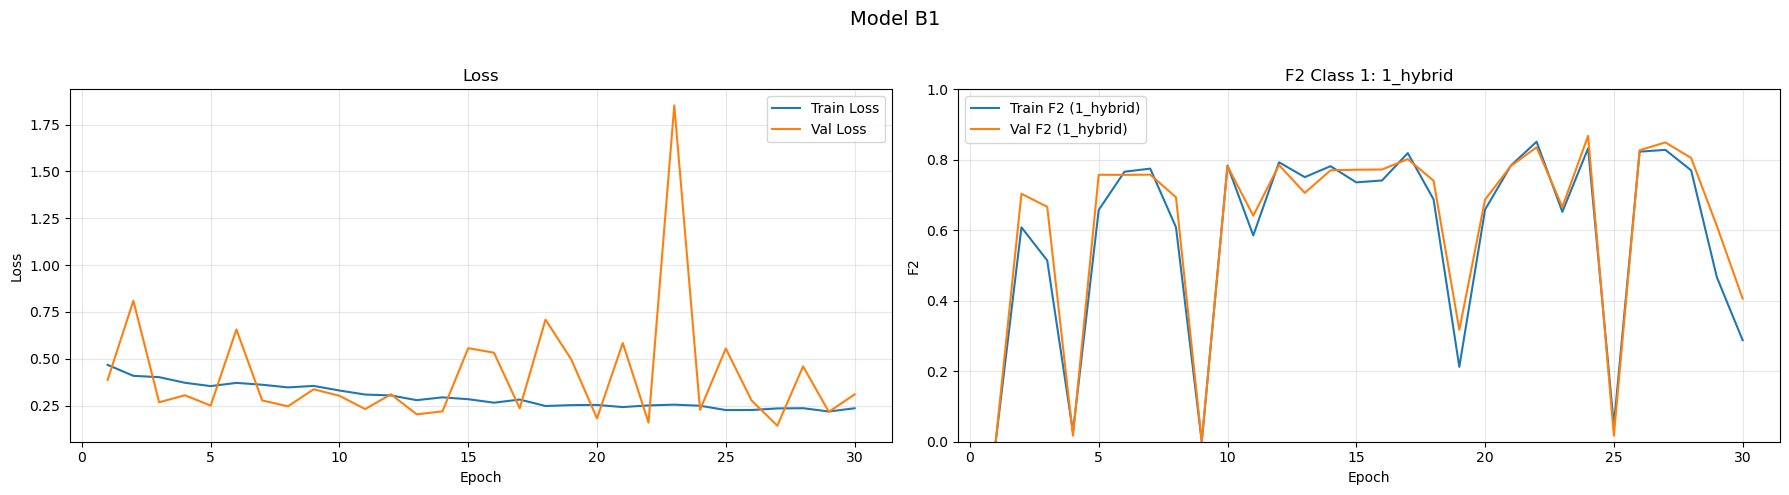

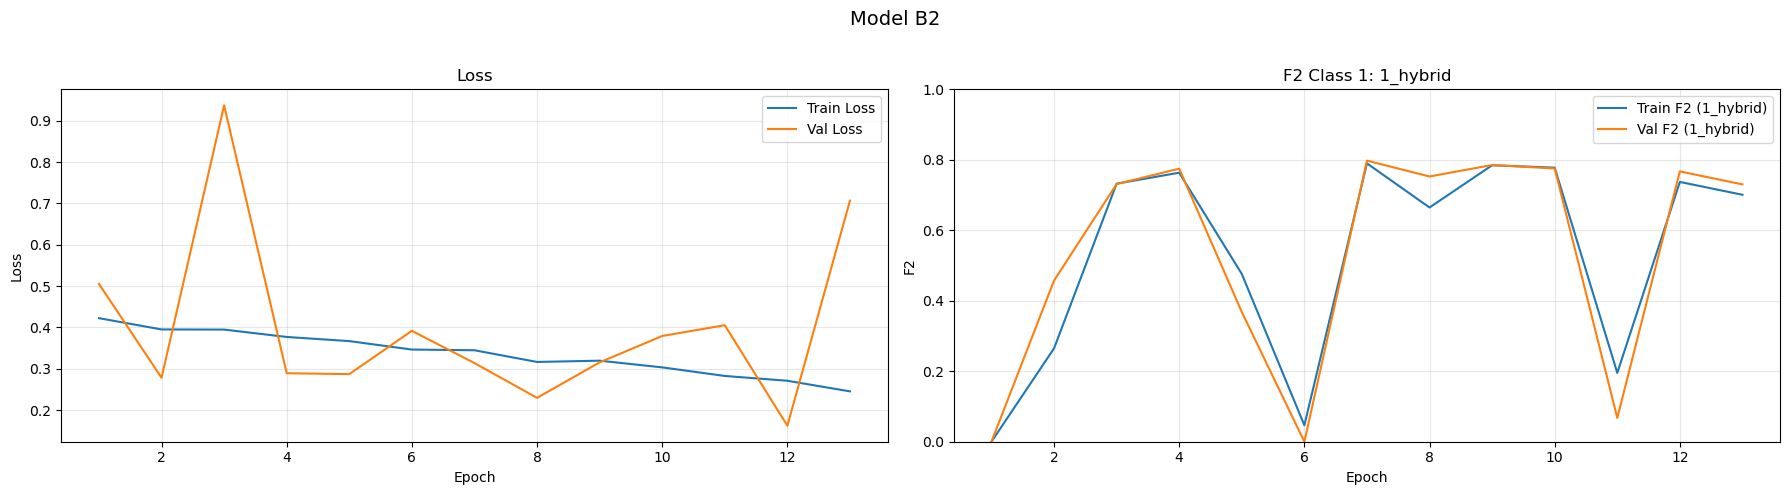

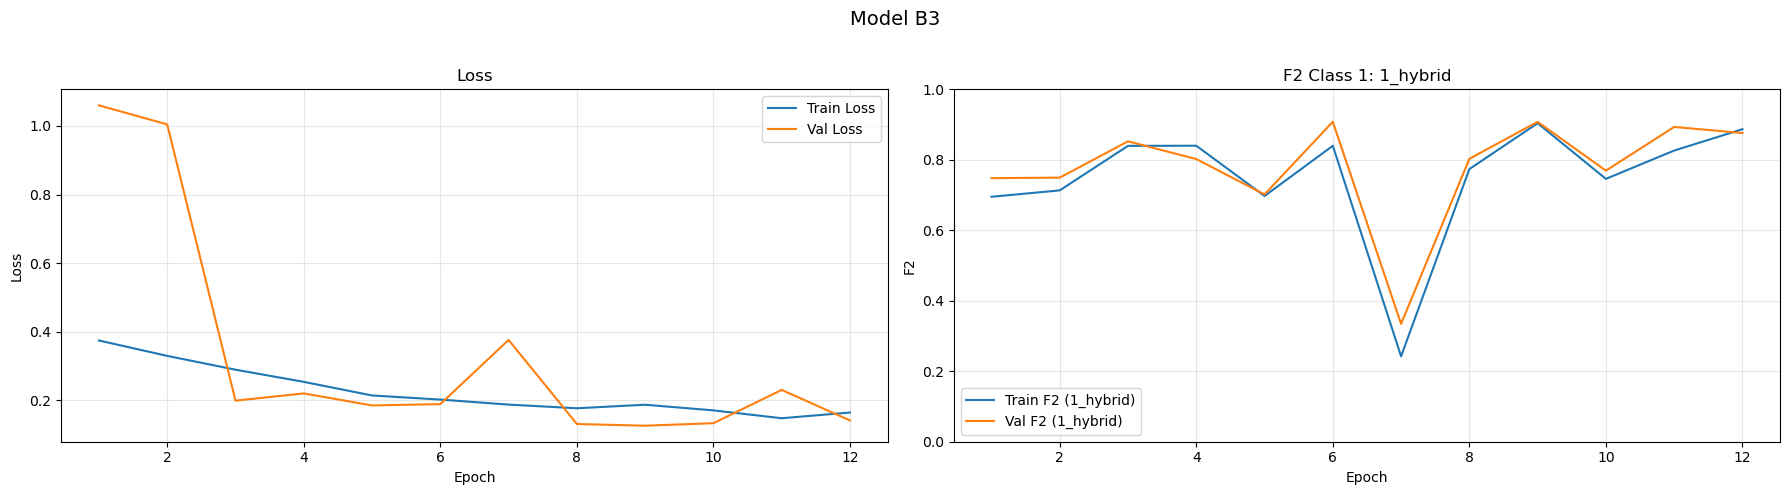

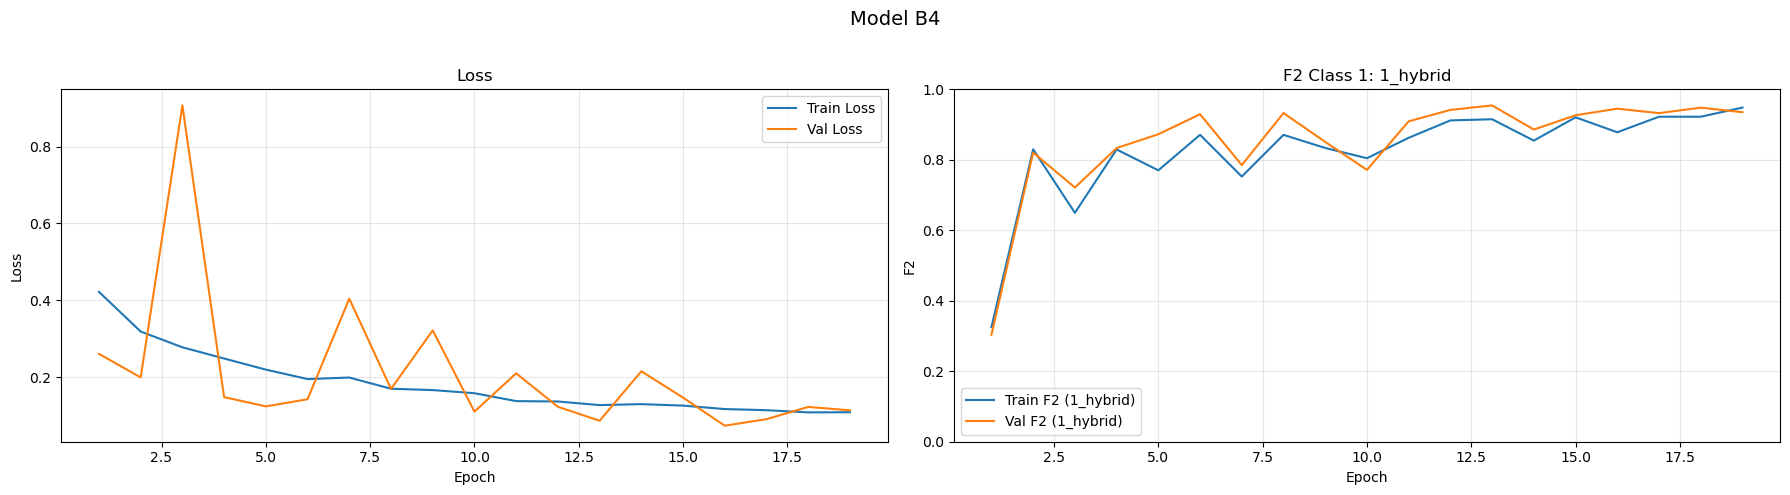

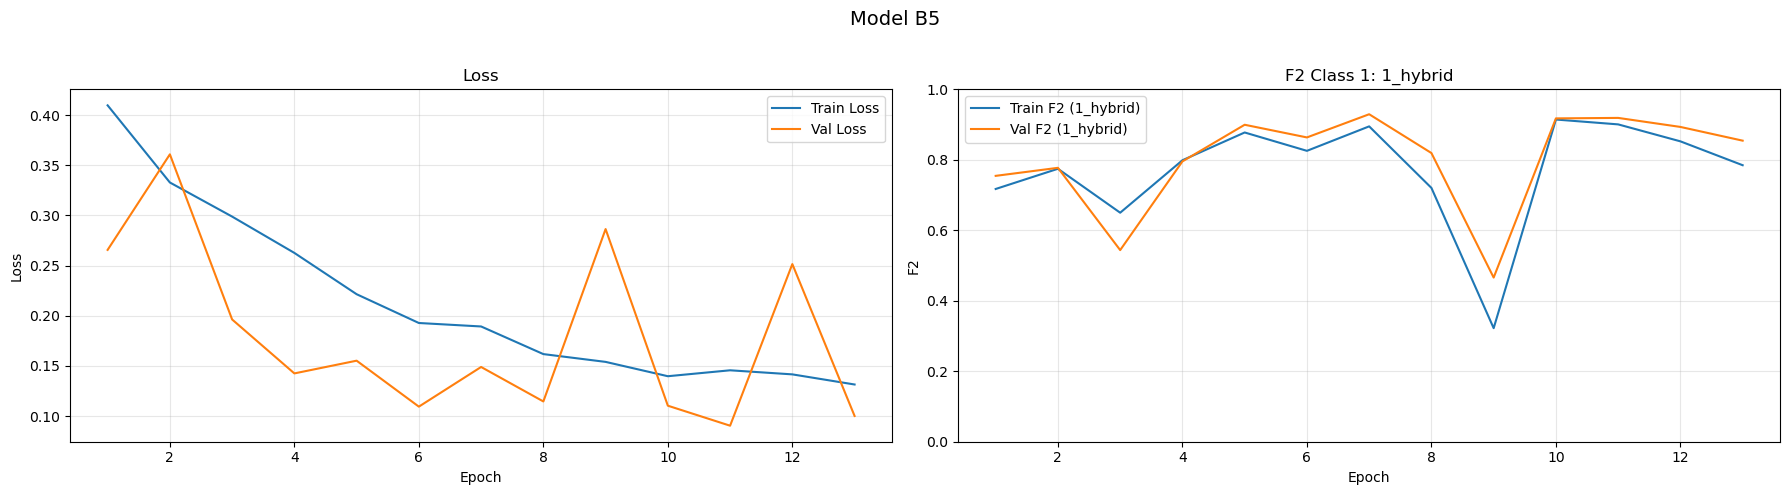

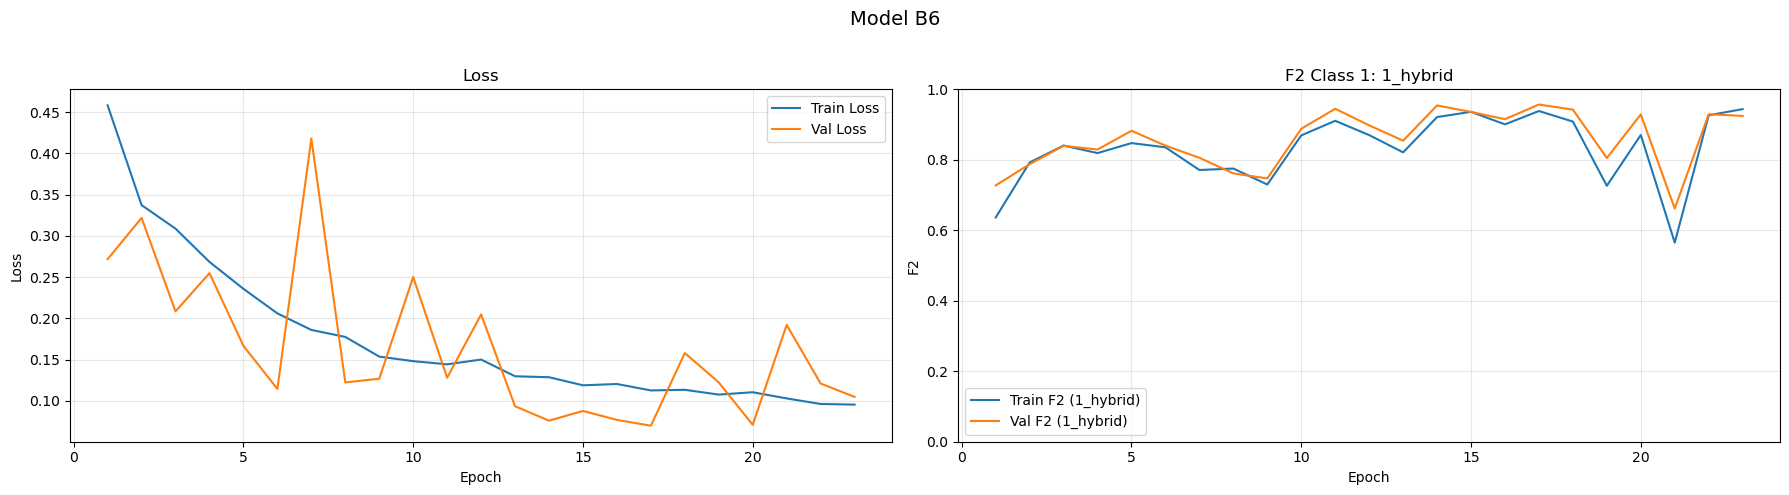

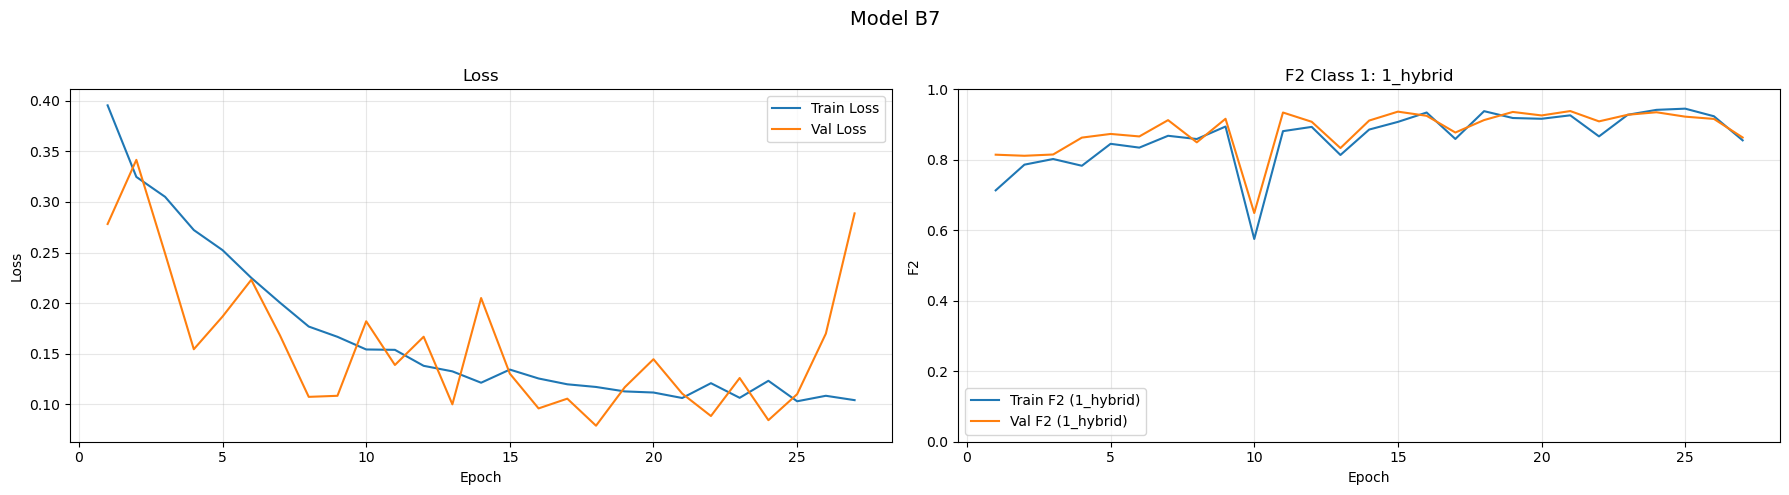

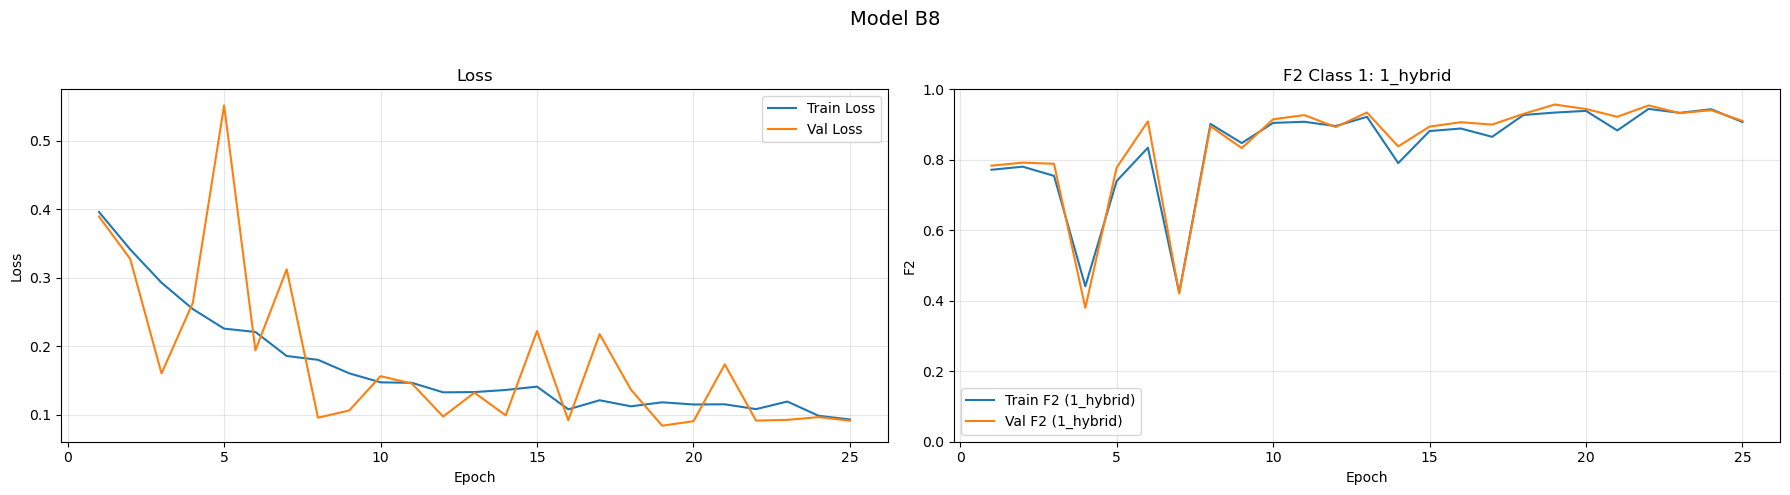

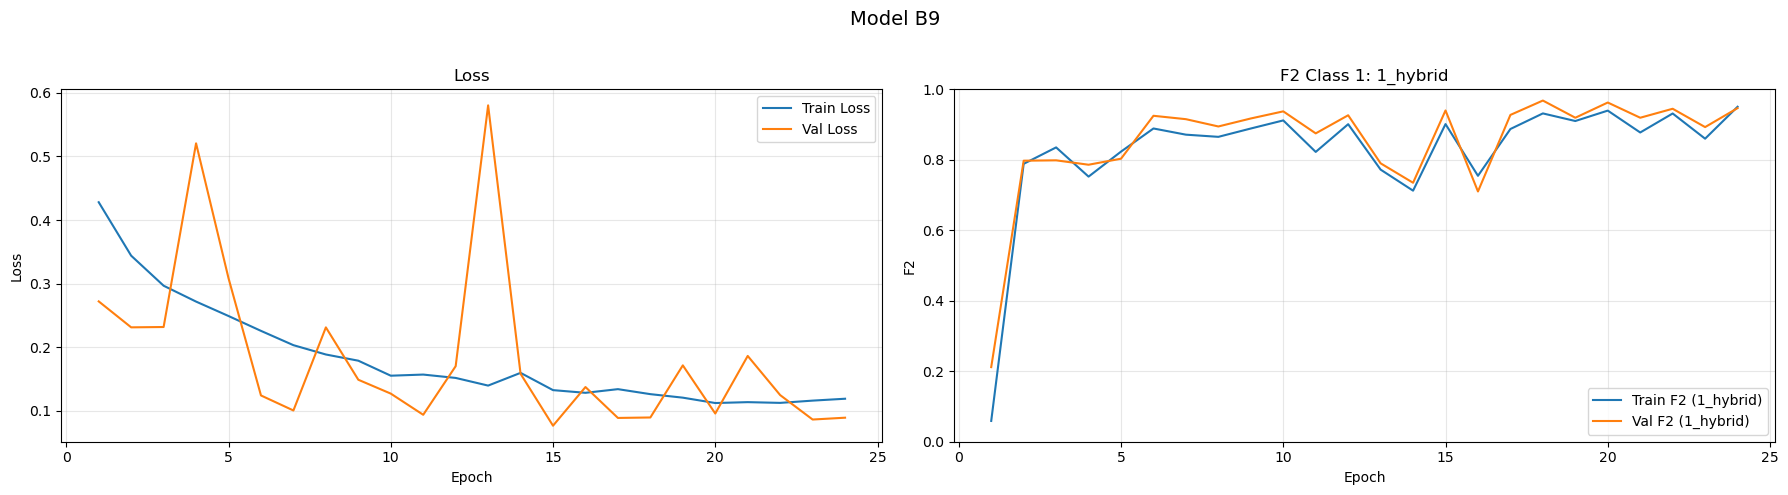

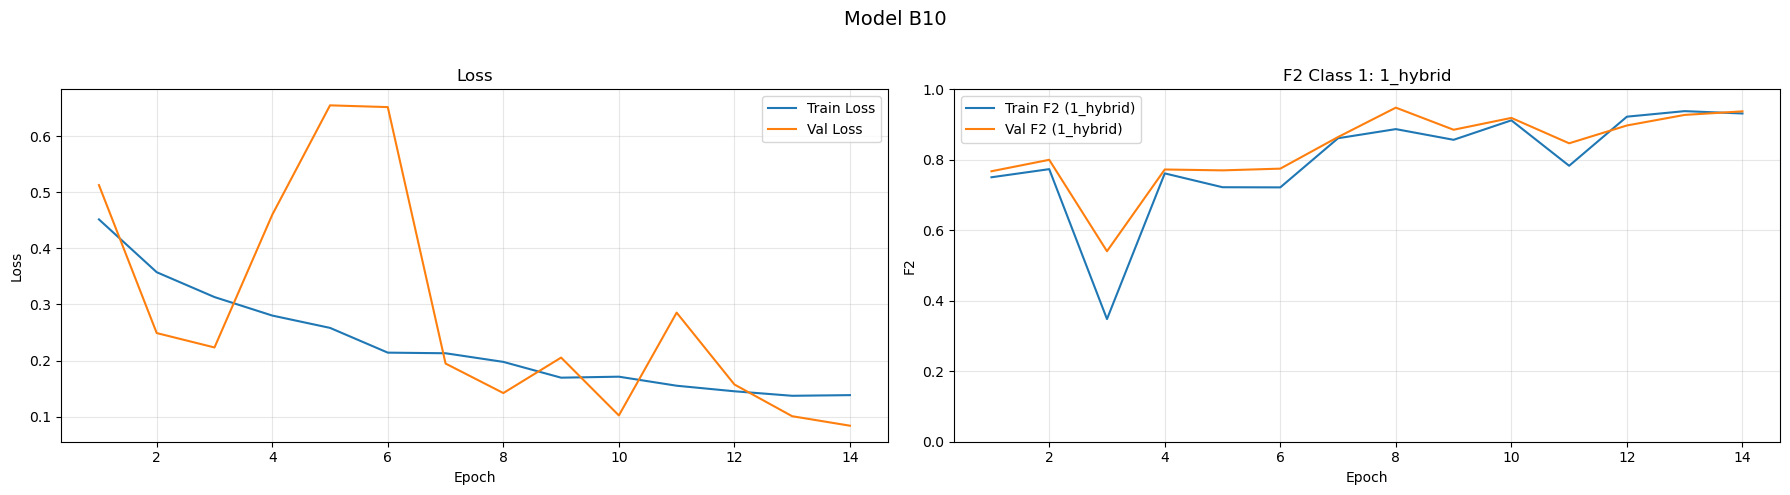

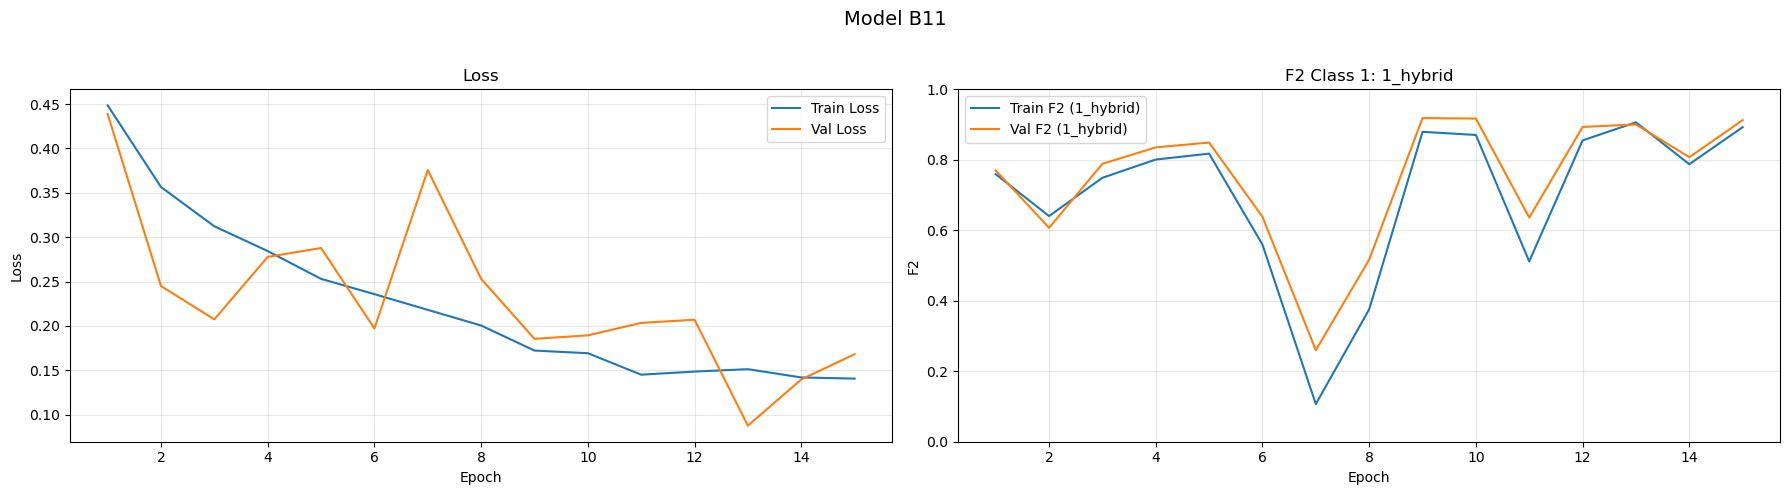

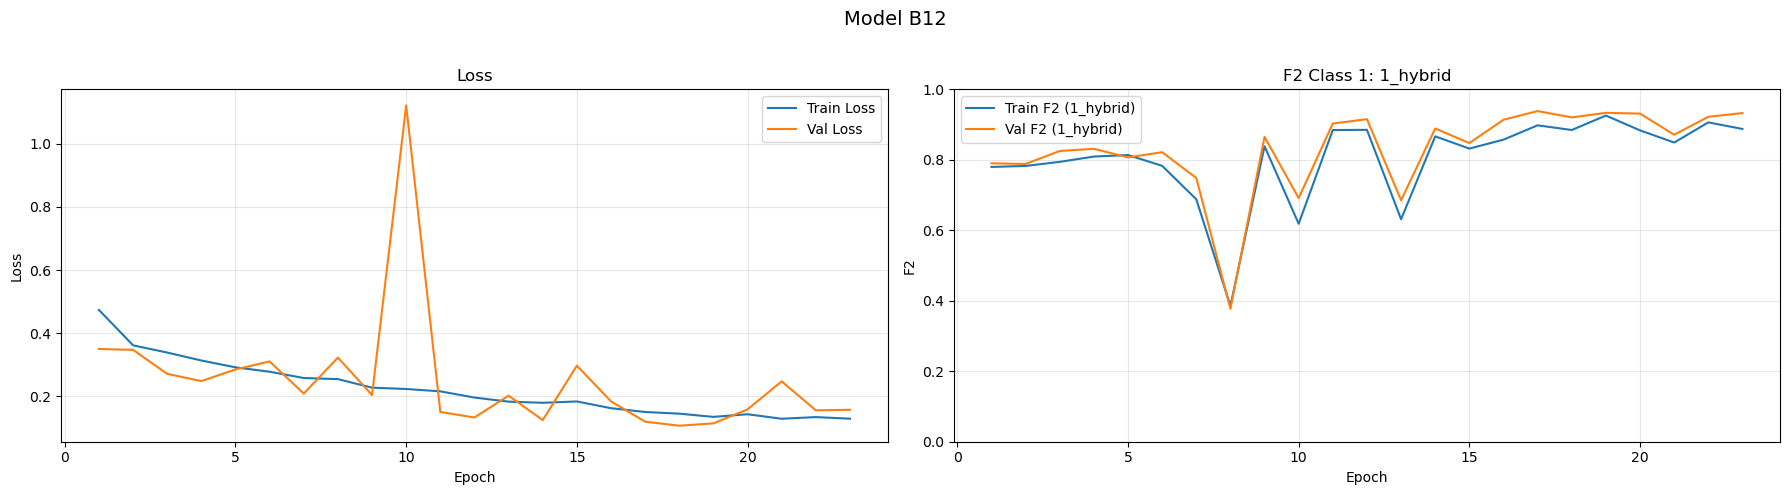

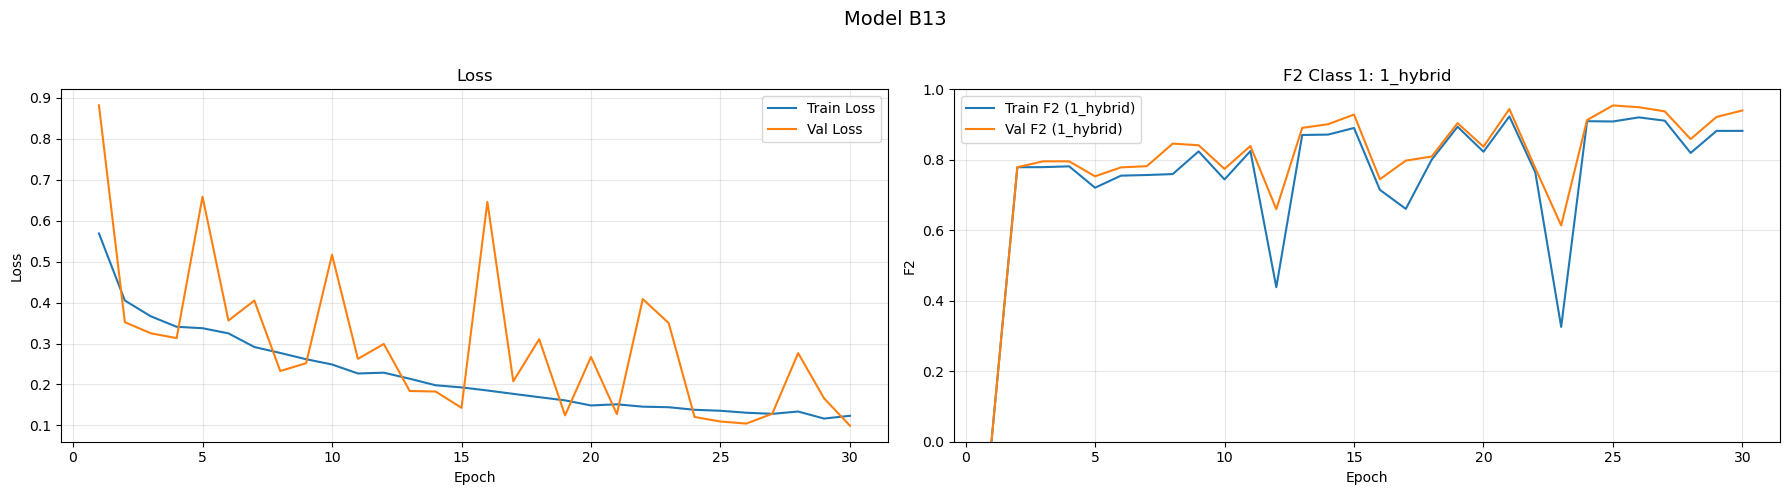

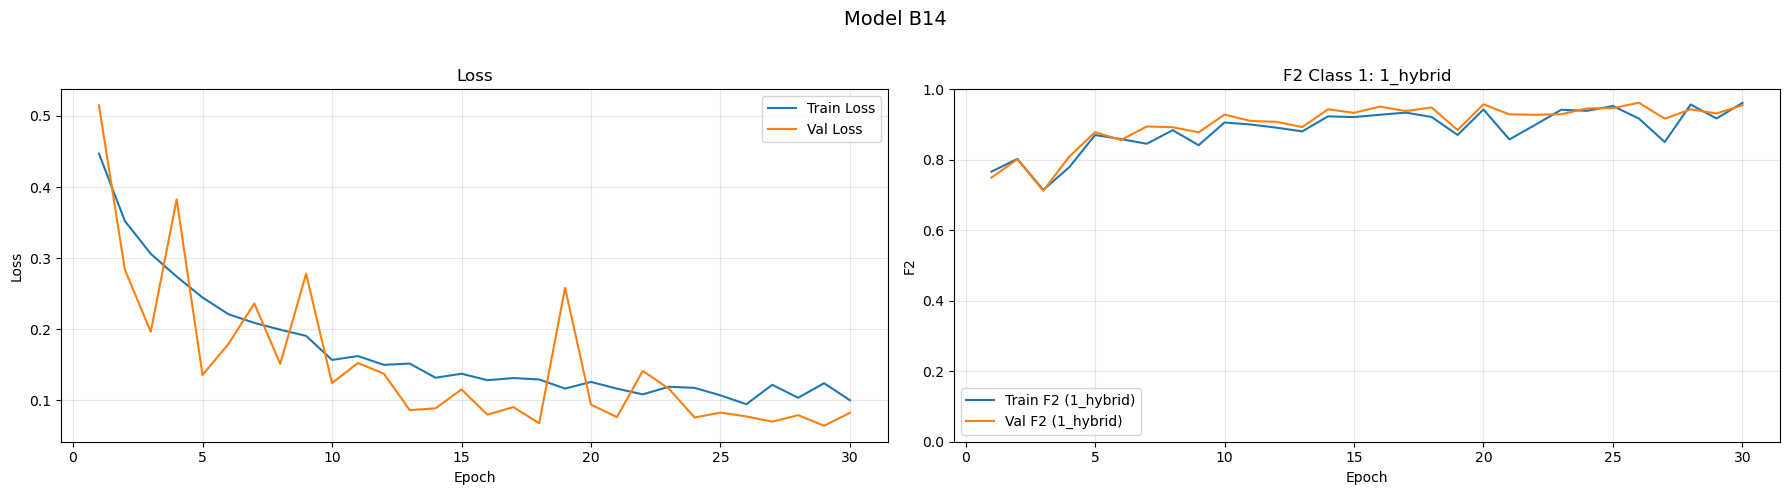

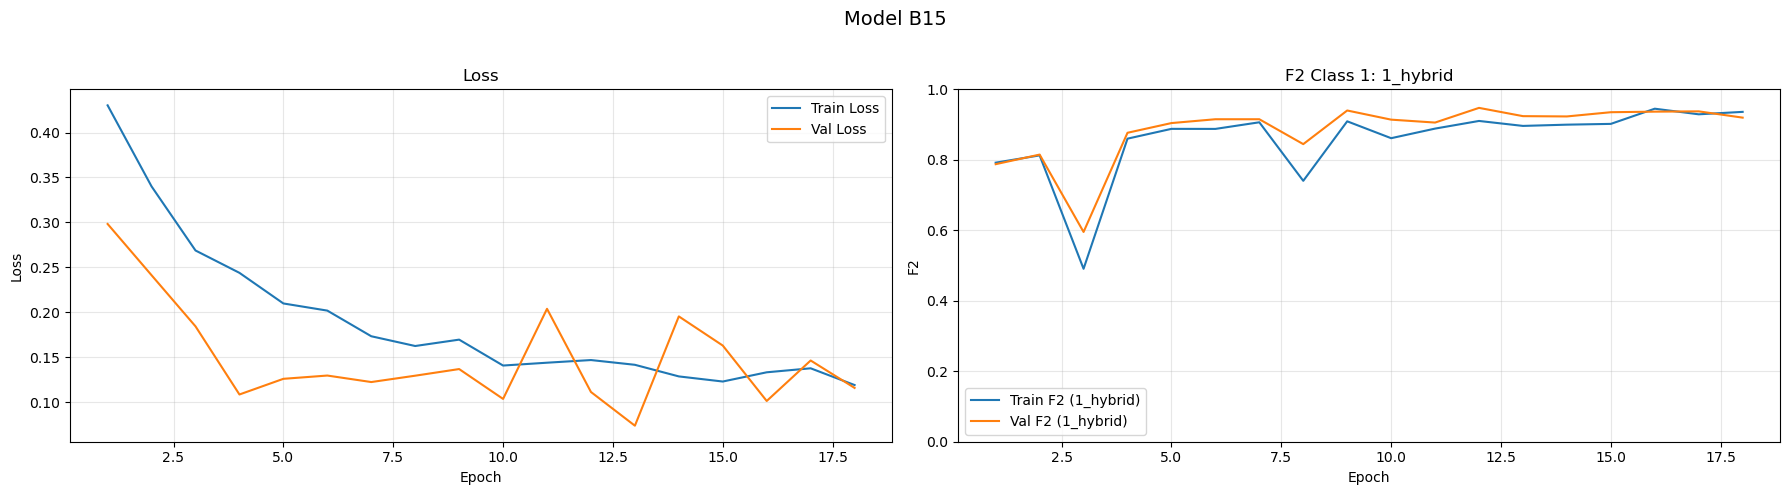

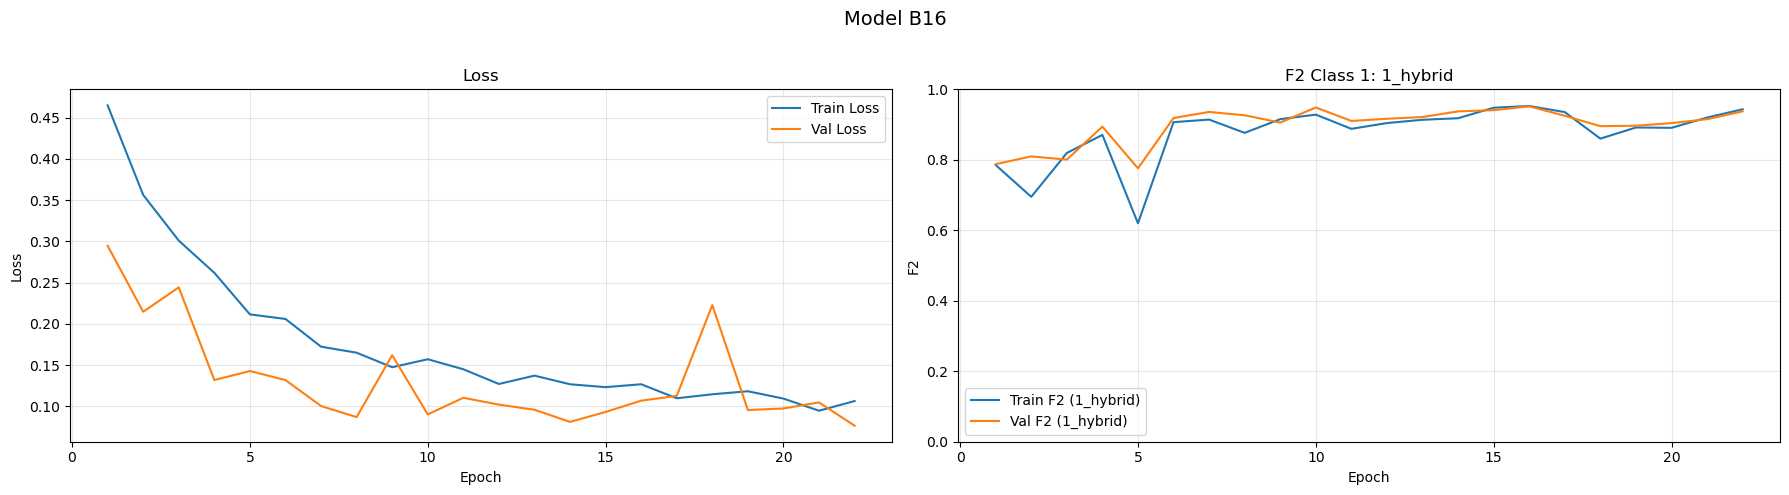

In [10]:
for i in range(1, 17):
    plot_training_curves(model_name=f"Model B{i}", results=results_from_ckpt(model=model_resnet_b_dict[f"model_resnet_b{i}"], ckpt_file=f"../../saved_models/resnet/resnet_b/resnet_model_b{i}_log.pkl"), class_idx=1, class_name="1_hybrid")